# AI Declaration

I have used ChatGPT 5.6. to refactor some of the code. There were no changes done to the fundamentals of the code, however some of the functions in the code were rewritten based on my earlier solutions (which were written without AI, but I was unsatisfied with the structure). This was done in order to split one large function into two smaller ones for exercise 4. This would most likely fall under a Level 2 contribution.


# Collaborators:

Johannes Schäfers, Steffen Pablo Krieg

# Exercises week 37

**FYS-STK3155/4155, fall 2026 — deadline Friday September 11 at midnight.**

## Implementing gradient descent for ordinary least squares and Ridge regression

The aim this week is that you write, and *check*, your own gradient descent
code for OLS and Ridge regression, and that you understand what the learning
rate can and cannot be. Everything here is reused directly in part e) of
Project 1, and exercise 6 opens part f). The code developed in the Tuesday
session (`week37tuesday.ipynb`, Case 1) is meant to be reused.

After completing these exercises you will have

* your own code for the simplest gradient descent approach applied to
  ordinary least squares (OLS) and Ridge regression, with a stopping criterion;
* compared the analytical expressions for the OLS and Ridge parameters with
  the gradient descent results;
* explored the role of the learning rate $\gamma$ in gradient descent and of the
  hyperparameter $\lambda$ in Ridge regression, and related the largest usable
  learning rate to the largest eigenvalue of the Hessian (Section 4.5 of the
  lecture notes);
* checked your analytical gradient against automatic differentiation
  (Section 4.14) and added momentum (Section 4.6);
* scaled the data properly.

Reading: Chapter 4, Sections 4.1–4.6 and 4.14 of the book; Goodfellow et al.,
Chapter 4 and Sections 8.1–8.3.

## A simple one-dimensional second-order polynomial

We start with a very simple function,

$$
f(x) = 2 - x + 5x^2,
$$

defined for $x \in [-2, 2]$. You can add noise if you wish (the Tuesday
session used Gaussian noise with standard deviation $0.5$). We fit this
function with a polynomial ansatz. The easiest thing is to set up a
second-order polynomial and see if you can recover the above function; feel
free to play around with higher-order polynomials — the Tuesday session shows
that a degree-5 fit of the same data is a much harder problem for gradient
descent, and exercise 4 asks you why.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

rng = np.random.default_rng(2026)
n = 100
x = rng.uniform(-2.0, 2.0, n)
y = 2.0 - x + 5.0 * x**2 + 0.5 * rng.standard_normal(n)   # drop the noise term if you prefer

## Exercise 1: scale your data

Before fitting a regression model it is good practice to standardise the
features. This ensures all features are on a comparable scale, which is
especially important when using regularisation — and, as Section 4.5 of the
lecture notes shows, it is also what makes gradient descent converge in a
reasonable number of iterations. Here we standardise, scaling each feature to
have mean $0$ and standard deviation $1$.

### 1a)

Set up the design matrix $\boldsymbol{X}$ with the columns $x$ and $x^2$ (no
column of ones). Compute the mean and standard deviation of each column,
subtract the mean and divide by the standard deviation.

We also centre the target $\boldsymbol{y}$ to mean $0$. Centring
$\boldsymbol{y}$ and each feature means the model does not need a separate
intercept term: the data are shifted so that the intercept is effectively
$0$. (In practice one can include an intercept in the model and leave it
unpenalised, see Section 3.13 of the lecture notes; here we simplify by
centring.)

In [3]:
X = np.column_stack([x, x**2])

# Standardize features (zero mean, unit variance for each feature)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1  # safeguard to avoid division by zero for constant features
X_norm = (X - X_mean) / X_std

# Center the target to zero mean (optional, to simplify intercept handling)
y_mean = y.mean()
y_centered = y - y_mean

Fill in the necessary details. Do we need to centre the $y$-values? What
would go wrong, for OLS and for Ridge, if we did not?

After this preprocessing each column of $\boldsymbol{X}_{\mathrm{norm}}$ has
mean zero and standard deviation $1$ and $\boldsymbol{y}_{\mathrm{centered}}$
has mean $0$. This makes the optimisation landscape nicer and ensures that the
penalty $\lambda\sum_j\theta_j^2$ in Ridge regression treats each coefficient
fairly, since the features are on the same scale.

### 1b)

The true function has coefficients $(-1, 5)$ on $(x, x^2)$. Which
coefficients do you expect to find on the *standardised* columns, and how do
you convert the fitted parameters back to the original scale?

The coefficients will be scaled, because of the division by the standard deviation.
Therefore the new coefficients will be scaled by a term of X_std

## Exercise 2: calculate the gradients and the Hessian

Find the gradients of the OLS and Ridge cost functions,

$$
C_{\mathrm{OLS}}(\boldsymbol{\theta}) = \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2,
\qquad
C_{\mathrm{Ridge}}(\boldsymbol{\theta}) = \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2 + \lambda\boldsymbol{\theta}^T\boldsymbol{\theta},
$$

with respect to $\boldsymbol{\theta}$ (Eqs. (4.13) and (4.17) of the lecture
notes). Find also the Hessian matrices, and show that the OLS Hessian is
positive semi-definite and the Ridge Hessian positive definite for
$\lambda > 0$ — that is, that both cost functions are convex (Section 4.1).
Why does this matter for gradient descent?

Setting the Ridge gradient to zero, show that the minimiser is
$\hat{\boldsymbol{\theta}} = (\boldsymbol{X}^T\boldsymbol{X} + n\lambda\boldsymbol{I})^{-1}\boldsymbol{X}^T\boldsymbol{y}$.
Where does the factor $n$ come from, and what is the corresponding `alpha`
of `scikit-learn`'s `Ridge`? (Section 3.10 and Eq. (3.95).)

Answer for exercise 2:



Gradient of Cost function for OLS can be derived as follows:

$\nabla C_{OLS} (\theta) = \nabla (\frac{1}{n}((X\theta)^2 - 2 y X \theta + y^2)) = \frac{1}{n} (2 X^T X \theta - 2 X^T y) = \frac{2}{n} X^T (X \theta - y)$

Similarly, for Ridge Regression this can be done as follows:

$\nabla C_{Ridge} (\theta) = \nabla (\frac{1}{n}(X\theta)^2 - 2 y X \theta + y^2 + \lambda \theta ^T \theta) = \frac{1}{n} (2 X^T X \theta - 2 X^T y + 2 \lambda \theta) = \frac{2}{n} (X^T X \theta - X^T y + \lambda \theta n)$

The Hessian can be found by once again derivating these expressions with respect to theta:

$\nabla \nabla C_{OLS} (\theta) = \nabla \frac{2}{n} X^T (X \theta + y) = \frac{2}{n} X^T X$

$\nabla \nabla C_{Ridge} (\theta) = \nabla \frac{2}{n} (X^T X \theta + X^T y + \lambda \theta n) = \frac{2}{n} (X^T X + \lambda n) $

We can show that the Hessian is positive sem-definite for OLS and that Ridge is positive definite for $\lambda > 0$ as follows:

$ z^T \frac{2}{n} X^TXz = \frac{2}{n}\lvert \lvert X z \rvert \rvert_2^2 \ge 0 $

$ z^T \frac{2}{n}  (X^TX + \lambda n) z = \frac{2}{n} \lvert \lvert X z \rvert \rvert_2^2 + 2\lambda \lvert \lvert z \rvert \rvert_2^2 \ge 0 $ (as long as $\lambda \ge 0$)

This matters for gradient descent, because the positive semi definiteness of these matrices guarantee the convexity and therefore also guarantee the existence of a global minimum, which is what we are trying to find when using Gradient descent.
To find the minimser of Ridge, the gradient of Ridge is set to zero.

$$\frac{2}{n} (X^T X \theta - X^T y + \lambda \theta n) = 0$$
$$ (X^T X \theta - X^T y + \lambda \theta n) = 0$$
$$ (X^T X \theta +  + \lambda \theta n) = X^T y$$
$$ (X^T X +  + \lambda  n I) \theta= X^T y$$
$$ \theta= (X^T X +  + \lambda  n I)^{-1}  X^T y$$

The factor n comes from the definition of our Cost function of Ridge. The normal OLS part of the cost function has a factor $ 1/n $, since it is equal to the mean squared error, whereas the penalty term of Ridge does not have such a factor. Scikit learn unifies the $n \lambda$ into a single factor $\alpha$.  

## Exercise 3: the analytical formulae for OLS and Ridge regression

Closed-form Ridge coefficients: [-0.90285632  5.24221637]
Closed-form OLS coefficients: [-1.0773505  5.854734 ]
Scikit-learn Ridge coefficients: [-0.90285632  5.24221637]


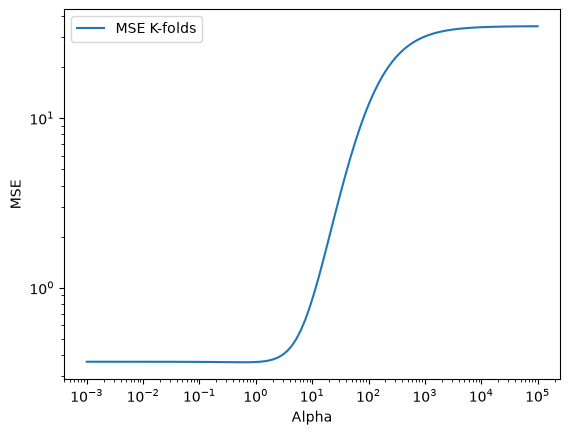

In [4]:
# Set regularization parameter, either a single value or a vector of values
# Note that lambda is a python keyword: the lambda keyword creates small anonymous functions.
lam = 0.1129

# Analytical forms: theta_Ridge = (X^T X + n*lambda*I)^{-1} X^T y and theta_OLS = (X^T X)^{-1} X^T y
n_features = X_norm.shape[1]
I = np.eye(n_features)
theta_closed_formRidge = np.linalg.inv(X_norm.T @ X_norm + n * lam * I) @ X_norm.T @ y_centered
theta_closed_formOLS = np.linalg.inv(X_norm.T @ X_norm) @ X_norm.T @ y_centered
theta_scikit = sklearn.linear_model.Ridge(alpha=n*lam, fit_intercept=False).fit(X_norm, y_centered).coef_

print("Closed-form Ridge coefficients:", theta_closed_formRidge)
print("Closed-form OLS coefficients:", theta_closed_formOLS)
print("Scikit-learn Ridge coefficients:", theta_scikit)


def K_fold_mse(x=None, y=None, n=100, k_folds = 5, deg = 6, alphas = np.logspace(-3, 5, 100), seed=2026):
    rng = np.random.default_rng(seed)

    # following block is created by Claude Sonnet 5
    # following prompt was used:
    '''I want to be able to use the same function on data looking like e.g. 

        x = np.linspace(-3, 3, n).reshape(-1, 1)
        y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

        please rewrite the function'''
    
    if x is None or y is None:
        x = rng.standard_normal(n)
        y = 3 * x**2 + rng.standard_normal(n)

    y = np.asarray(y).ravel()   

    folds = sklearn.model_selection.KFold(n_splits=k_folds, shuffle=True, random_state=seed)
    polynomial = sklearn.preprocessing.PolynomialFeatures(degree=deg)

    scores = np.zeros((len(alphas), k_folds))
    for i, alpha in enumerate(alphas):
        for j, (train_idx, test_idx) in enumerate(folds.split(x)):
            xtrain, ytrain = x[train_idx,:], y[train_idx]
            xtest, ytest = x[test_idx,:], y[test_idx]

            ridge = sklearn.linear_model.Ridge(alpha=alpha)
            ridge.fit(xtrain, ytrain)
            y_tilde = ridge.predict(xtest)

            scores[i, j] = np.mean((ytest - y_tilde)**2)

    mse_kfolds = np.mean(scores, axis=1)
    return alphas, mse_kfolds

alphas, mse_kfolds = K_fold_mse(x=X_norm, y=y_centered, n=n, k_folds=5, deg=2, alphas=np.logspace(-3, 5, 100))
#print ("Alphas:", alphas) 
#print("MSE K-folds:", mse_kfolds)

fig, ax = plt.subplots()
ax.loglog(alphas, mse_kfolds, label='MSE K-folds')
ax.set_xlabel('Alpha')
ax.set_ylabel('MSE')
ax.legend()
plt.show()

m = np.argmin(mse_kfolds)
lam = alphas[m]/n

This computes the Ridge and OLS regression coefficients directly. The identity
matrix $\boldsymbol{I}$ has the same size as $\boldsymbol{X}^T\boldsymbol{X}$
and adds $n\lambda$ to its diagonal for Ridge regression. We then solve the
linear system (prefer `np.linalg.solve` or `np.linalg.pinv` to an explicit
inverse). The result for $\boldsymbol{\theta}$ is a NumPy array of shape
`(n_features,)` containing the fitted parameters.

### 3a)

Finalise, in the above code, the OLS and Ridge regression determination of
the optimal parameters $\boldsymbol{\theta}$. Compare with
`Ridge(alpha=n*lam, fit_intercept=False)` from `scikit-learn`.

### 3b)

Explore the results as functions of different values of the hyperparameter
$\lambda$. See for example exercise 4 from week 36, and Section 3.14 of the
lecture notes for how $\lambda$ should be chosen in practice.

## Exercise 4: implementing the simplest form of gradient descent

Alternatively we can fit the model by gradient descent, Eq. (4.15) of the
lecture notes,

$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \gamma\,\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}_k).
$$

This is useful to visualise the iterative convergence, and it is necessary
when $n$ and $p$ are so large that the closed form is too slow or too
memory-hungry — or when, as for the Lasso, logistic regression and neural
networks, no closed form exists. Use the gradients of exercise 2 and set up,
using the template below, your own gradient descent code for OLS and Ridge
regression.

eta=0.1: OLS converged in 104 iterations, Ridge converged in 103 iterations
eta=0.3: OLS converged in 27 iterations, Ridge converged in 27 iterations
eta=0.8: OLS converged in 84 iterations, Ridge converged in 88 iterations


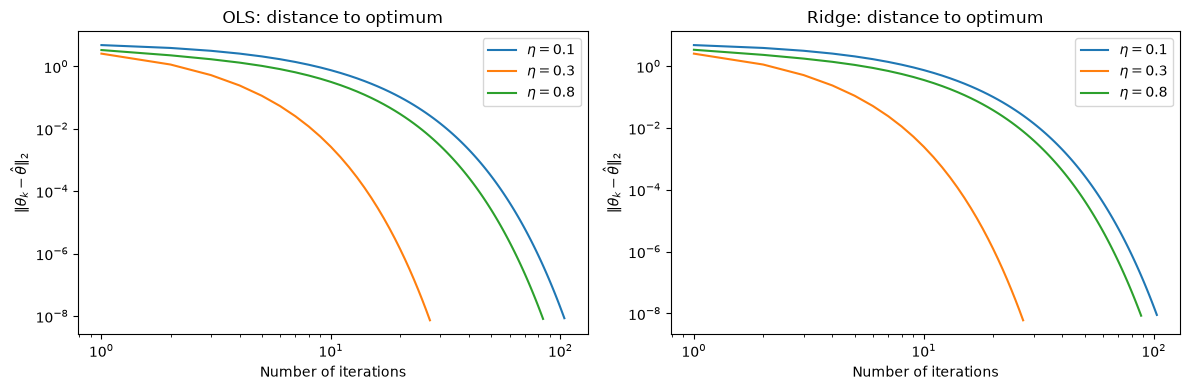

In [6]:
# Gradient descent parameters, learning rate eta first
eta = 0.1
etas = [0.1, 0.3, 0.8]
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 1000
tol = 1e-8

def grad_OLS(X, y, n, theta):
    return (2/n) * X.T @ (X @ theta -y)

def OLS_gd(X, y, eta, num_iters, tol):
    n_samples, n_features = X.shape

    theta_opt = np.linalg.solve(X.T @ X, X.T @ y)
    theta = np.zeros(n_features)

    distances = []
    iterations = num_iters

    for iteration in range(num_iters):
        gradient = grad_OLS(X, y, n_samples ,theta)
        theta_new = theta - eta * gradient

        distance = np.linalg.norm(theta_new - theta_opt)
        distances.append(distance)

        theta = theta_new

        if distance < tol:
            iterations = iteration + 1
            break

    return np.asarray(distances), iterations, theta

def grad_Ridge(X, y, n, theta, lam):
    return (2/n) * X.T @ (X @ theta -y) + 2 * lam * theta


def Ridge_gd(X, y, eta, num_iters, tol, lam):
    n_samples, n_features = X.shape

    theta_opt = np.linalg.solve(
        X.T @ X + n_samples * lam * np.eye(n_features),
        X.T @ y
    )

    theta = np.zeros(n_features)
    distances = []

    for iteration in range(num_iters):
        gradient = grad_Ridge(X, y, n_samples, theta, lam)

        theta = theta - eta * gradient
        distance = np.linalg.norm(theta - theta_opt)
        distances.append(distance)

        if distance < tol:
            return np.asarray(distances), iteration + 1, theta

    return np.asarray(distances), num_iters, theta


def plot_convergence(X, y, lam, etas, num_iters, tol):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for eta in etas:
        distance_ols, iterations_ols, _ = OLS_gd(
            X, y, eta, num_iters, tol
        )
        distance_ridge, iterations_ridge, _ = Ridge_gd(
            X, y, eta, num_iters, tol, lam
        )

        axes[0].loglog(
            np.arange(1, len(distance_ols) + 1),
            distance_ols,
            label=fr"$\eta={eta}$"
        )
        axes[1].loglog(
            np.arange(1, len(distance_ridge) + 1),
            distance_ridge,
            label=fr"$\eta={eta}$"
        )

        print(
            f"eta={eta}: "
            f"OLS converged in {iterations_ols} iterations, "
            f"Ridge converged in {iterations_ridge} iterations"
        )

    axes[0].set_title("OLS: distance to optimum")
    axes[1].set_title("Ridge: distance to optimum")

    for axis in axes:
        axis.set_xlabel("Number of iterations")
        axis.set_ylabel(r"$\|\theta_k-\hat{\theta}\|_2$")
        axis.legend()

    plt.tight_layout()
    plt.show()


def test_max_eta(X, y, lam, num_iters, tol):
    n_samples, n_features = X.shape

    hessian_ols = (2 / n_samples) * X.T @ X
    hessian_ridge = hessian_ols + 2 * lam * np.eye(n_features)

    eigen_ols = np.linalg.eigvalsh(hessian_ols)
    eigen_ridge = np.linalg.eigvalsh(hessian_ridge)

    max_eta_ols = 2 / eigen_ols.max()
    max_eta_ridge = 2 / eigen_ridge.max()

    kappa_ols = eigen_ols.max() / eigen_ols.min()
    kappa_ridge = eigen_ridge.max() / eigen_ridge.min()

    distance_ols_small, _, _ = OLS_gd(
        X, y, 0.99 * max_eta_ols, num_iters, tol
    )
    distance_ols_large, _, _ = OLS_gd(
        X, y, 1.01 * max_eta_ols, num_iters, tol
    )

    distance_ridge_small, _, _ = Ridge_gd(
        X, y, 0.99 * max_eta_ridge, num_iters, tol, lam
    )
    distance_ridge_large, _, _ = Ridge_gd(
        X, y, 1.01 * max_eta_ridge, num_iters, tol, lam
    )

    return {
        "distance_ols_small": distance_ols_small,
        "distance_ols_large": distance_ols_large,
        "distance_ridge_small": distance_ridge_small,
        "distance_ridge_large": distance_ridge_large,
        "max_eta_ols": max_eta_ols,
        "max_eta_ridge": max_eta_ridge,
        "kappa_ols": kappa_ols,
        "kappa_ridge": kappa_ridge,
    }


plot_convergence(
    X_norm, y_centered, lam, etas, num_iters, tol
)

results_degree_2 = test_max_eta(
    X_norm, y_centered, lam, num_iters, tol
)

# Keep the original variable names for later cells.
distanceetasmall = results_degree_2["distance_ols_small"]
distanceetalarge = results_degree_2["distance_ols_large"]
distanceetaRidgesmall = results_degree_2["distance_ridge_small"]
distanceRidgelarge = results_degree_2["distance_ridge_large"]
max_eta_OLS = results_degree_2["max_eta_ols"]
max_eta_Ridge = results_degree_2["max_eta_ridge"]
kappaOLS = results_degree_2["kappa_ols"]
kappaRidge = results_degree_2["kappa_ridge"]


# Degree-5 polynomial
X_5 = np.column_stack([x, x**2, x**3, x**4, x**5])

X_5_mean = X_5.mean(axis=0)
X_5_std = X_5.std(axis=0)
X_5_std[X_5_std == 0] = 1

X_5_norm = (X_5 - X_5_mean) / X_5_std

results_degree_5 = test_max_eta(
    X_5_norm, y_centered, lam, num_iters, tol
)

distanceetasmall_5 = results_degree_5["distance_ols_small"]
distanceetalarge_5 = results_degree_5["distance_ols_large"]
distanceetaRidgesmall_5 = results_degree_5["distance_ridge_small"]
distanceRidgelarge_5 = results_degree_5["distance_ridge_large"]
max_eta_OLS_5 = results_degree_5["max_eta_ols"]
max_eta_Ridge_5 = results_degree_5["max_eta_ridge"]
kappaOLS_5 = results_degree_5["kappa_ols"]
kappaRidge_5 = results_degree_5["kappa_ridge"]

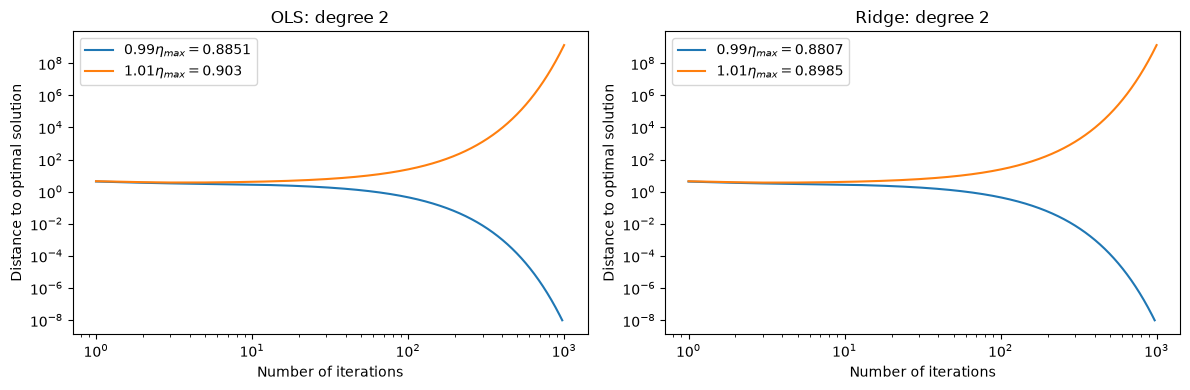

For degree 2: the Kappa value for OLS is 1.2687690135310865, and for Ridge it is 1.2670751883802216


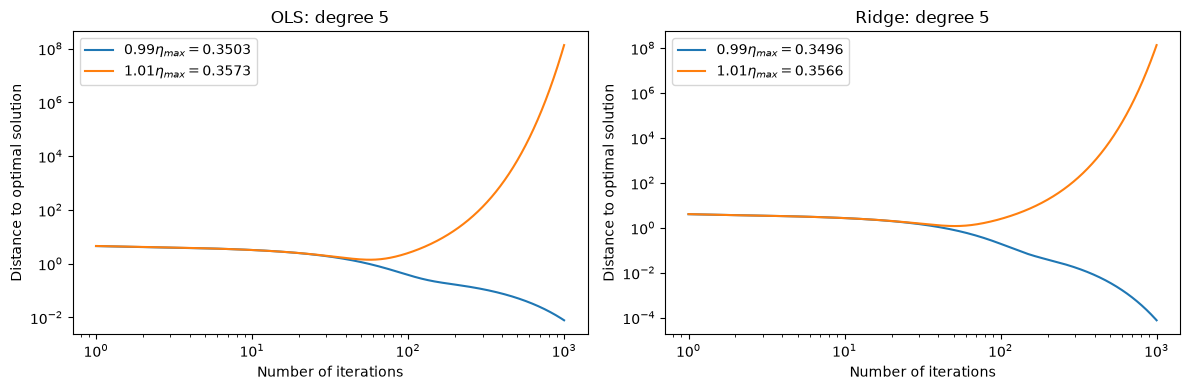

For degree 5: the Kappa value for OLS is 520.3442674565971, and for Ridge it is 256.9244271453093


In [7]:
def plot_eta_boundary(results, title, kappa_ols, kappa_ridge):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].loglog(
        np.arange(1, len(results["distance_ols_small"]) + 1),
        results["distance_ols_small"],
        label=f"$0.99\\eta_{{max}}={0.99 * results['max_eta_ols']:.4g}$"
    )
    axes[0].loglog(
        np.arange(1, len(results["distance_ols_large"]) + 1),
        results["distance_ols_large"],
        label=f"$1.01\\eta_{{max}}={1.01 * results['max_eta_ols']:.4g}$"
    )

    axes[1].loglog(
        np.arange(1, len(results["distance_ridge_small"]) + 1),
        results["distance_ridge_small"],
        label=f"$0.99\\eta_{{max}}={0.99 * results['max_eta_ridge']:.4g}$"
    )
    axes[1].loglog(
        np.arange(1, len(results["distance_ridge_large"]) + 1),
        results["distance_ridge_large"],
        label=f"$1.01\\eta_{{max}}={1.01 * results['max_eta_ridge']:.4g}$"
    )

    axes[0].set_title(f"OLS: {title}")
    axes[1].set_title(f"Ridge: {title}")

    for axis in axes:
        axis.set_xlabel("Number of iterations")
        axis.set_ylabel("Distance to optimal solution")
        axis.legend()

    plt.tight_layout()
    plt.show()

    print(
        f"For {title}: the Kappa value for OLS is {kappa_ols}, "
        f"and for Ridge it is {kappa_ridge}"
    )


plot_eta_boundary(
    results_degree_2,
    "degree 2",
    kappaOLS,
    kappaRidge
)

plot_eta_boundary(
    results_degree_5,
    "degree 5",
    kappaOLS_5,
    kappaRidge_5
)

### 4a)

Write first a gradient descent code for OLS only, using the above template.
Discuss the results as functions of the learning rate and the number of
iterations: for $\gamma \in \{0.01, 0.1, 0.5, 0.8\}$, how many iterations are
needed to reach the closed-form solution of exercise 3 to a given accuracy,
say $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|_2 < 10^{-6}$?
Plot this distance against the iteration number on a logarithmic scale.

### 4b)

Write then a similar code for Ridge regression. Add a stopping criterion
based on the number of iterations *and* on the size of the gradient (or on
the difference between the new and old $\boldsymbol{\theta}$). How would you
define a stopping criterion, and what goes wrong with a fixed number of
iterations alone?

### 4c) The learning rate and the eigenvalues of the Hessian

Compute the eigenvalues $\lambda_{\max}$ and $\lambda_{\min}$ of the Hessian
matrix of exercise 2 (use `np.linalg.eigvalsh`). Section 4.5 of the lecture
notes shows that gradient descent converges if and only if
$\gamma < 2/\lambda_{\max}$, Eq. (4.20), that the fastest convergence is
obtained for $\gamma^* = 2/(\lambda_{\max} + \lambda_{\min})$, and that the
number of iterations grows with the condition number
$\kappa = \lambda_{\max}/\lambda_{\min}$, Eq. (4.21). Verify the bound
numerically: run your code at $0.99 \cdot 2/\lambda_{\max}$ and at
$1.02 \cdot 2/\lambda_{\max}$.

Repeat for a design matrix with the columns $x, x^2, \dots, x^5$
(standardised). What happens to $\kappa$, to $\gamma_{\max}$ and to the number
of iterations, and why? Which of the two data sets does Ridge regression help
more, and in what sense?

### Answer to 4c)

Ridge helps the case of a degree 5 polynomial much more as it shrinks the condition number of the matrix to about half of the condition number of OLS, which makes the model less vulnerable to noise and overfitting.
For the degree 2 polynomial this does not happen. The condition number for OLS is already relatively low and the condition number for ridge is not much lower, therefore no large benefit is to be expected from the additional penealty term of Ridge regression.

### 4d) Checking the gradient with automatic differentiation

Project 1, part e), asks you to compute the gradient in two independent ways:
analytically, and by automatic differentiation. Write the OLS and Ridge cost
functions as ordinary Python functions of $\boldsymbol{\theta}$ using
`jax.numpy`, obtain their gradients with `jax.grad`, and compare with your
analytical gradients from exercise 2 at a random $\boldsymbol{\theta}$
(Section 4.14.7 of the lecture notes; remember
`jax.config.update("jax_enable_x64", True)`). Run your gradient descent code
with the automatic gradient and check that you obtain the same iterates.

In one or two sentences: why is automatic differentiation neither symbolic
nor numerical (finite-difference) differentiation, and what does a gradient
cost relative to one evaluation of the cost function (Section 4.14.4)?

In [8]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import grad

def cost_OLS(theta, X, y):
    return 1/n * jnp.linalg.norm(X@theta -y)**2

def cost_Ridge(theta, X, y, lam):
    return 1/n * jnp.linalg.norm(X@theta -y) + lam * theta.T @ theta

theta_test = rng.standard_normal(n_features)
grad_OLS_ad = grad(cost_OLS)(theta_test, jnp.asarray(X_norm), jnp.asarray(y_centered))
grad_OLS_analytical = 2/n *X_norm.T @ ( X_norm @ theta_test - y_centered)
print("max |AD - analytical| =", np.max(np.abs(np.asarray(grad_OLS_ad) - grad_OLS_analytical)))

max |AD - analytical| = 1.7763568394002505e-15


## Exercise 5: Ridge regression and a new synthetic data set

We create a synthetic linear regression data set with a sparse underlying
relationship: many features, of which only a few contribute to the target. We
use 10 features with only 3 non-zero weights in the true model, so that the
target is a linear combination of a few features (with known coefficients)
plus random noise. The steps are:

* decide on the number of samples and features (100 samples, 10 features);
* define the *true* coefficient vector with mostly zeros, for example
  $\boldsymbol{\theta}_{\mathrm{true}} = [5.0, -3.0, 0, 0, 0, 0, 2.0, 0, 0, 0]$,
  meaning only features 0, 1 and 6 have a real effect on $y$;
* sample the feature matrix $\boldsymbol{X}$ from a standard normal
  distribution, so that the features are roughly centred around 0;
* compute $\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta}_{\mathrm{true}} + \boldsymbol{\varepsilon}$
  with Gaussian noise $\boldsymbol{\varepsilon}$.

In [23]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(0)

# Define dataset size
n_samples = 100
n_features = 10

# Define true coefficients (sparse linear relationship)
theta_true = np.array([5.0, -3.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0])

# Generate feature matrix X (n_samples x n_features) with random values
X = np.random.randn(n_samples, n_features)  # standard normal distribution

# Generate target values y with a linear combination of X and theta_true, plus noise
noise = 2 * np.random.randn(n_samples)    # Gaussian noise
y = X @ theta_true + noise

In [24]:
# Standardize features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1

X_norm = (X - X_mean) / X_std

# Center target
y_mean = y.mean()
y_centered = y - y_mean

# Closed-form solutions
n_samples, n_features = X_norm.shape

theta_closed_form_ridge = np.linalg.solve(
    X_norm.T @ X_norm + n_samples * lam * np.eye(n_features),
    X_norm.T @ y_centered
)

theta_closed_form_ols = np.linalg.solve(
    X_norm.T @ X_norm,
    X_norm.T @ y_centered
)

# Gradient-descent solutions
eta = 0.1
num_iters_ex5 = 10000
tol_ex5 = 10**(-7)

distanceeta, iterationsOLS, theta_gdOLS_ex5 = OLS_gd(
    X_norm,
    y_centered,
    eta,
    num_iters_ex5,
    tol_ex5
)

distanceetaRidge, iterationsRidge, theta_gdRidge_ex5 = Ridge_gd(
    X_norm,
    y_centered,
    eta,
    num_iters_ex5,
    tol_ex5,
    lam
)

print(
    "The coef from the closed-form OLS were:",
    np.round(theta_closed_form_ols, decimals=5),
    ".\nWhile the gradient descent yielded:",
    np.round(theta_gdOLS_ex5, decimals=5)
)

print(
    "The coef from the closed-form Ridge were:",
    np.round(theta_closed_form_ridge, decimals=5),
    ".\nWhile the gradient descent yielded:",
    np.round(theta_gdRidge_ex5, decimals=5)
)

The coef from the closed-form OLS were: [ 5.07627 -2.89712 -0.06208  0.60718 -0.27332 -0.17606  1.91213  0.01751
  0.18102 -0.19904] .
While the gradient descent yielded: [ 5.07627 -2.89712 -0.06208  0.60718 -0.27332 -0.17606  1.91213  0.01751
  0.18102 -0.19904]
The coef from the closed-form Ridge were: [ 5.04698 -2.87734 -0.06182  0.60726 -0.27732 -0.17892  1.90266  0.01858
  0.17424 -0.19807] .
While the gradient descent yielded: [ 5.04698 -2.87734 -0.06182  0.60726 -0.27732 -0.17892  1.90266  0.01858
  0.17424 -0.19807]


In [25]:
print("To find which of the two regression models works better, we can compute the norm of the distance between the true coefficients and the calculated coefficietns. (using the L2-norm)\n")
print(
    "For OLS this was",
    np.linalg.norm(theta_closed_form_ols - theta_true)
)

print(
    "For Ridge this was",
    np.linalg.norm(theta_closed_form_ridge - theta_true)
)

To find which of the two regression models works better, we can compute the norm of the distance between the true coefficients and the calculated coefficietns. (using the L2-norm)

For OLS this was 0.7583128011531217
For Ridge this was 0.7603748378658471


Therefore Ridge regression does not fit the true parameters of the model better than normal OLS regression, when measuring using the norm of the difference between the true parameters and the calculated coefficients.

In [26]:
Hessian_OLS = 2/ n * X_norm.T @ X_norm
Hessian_Ridge = 2 / n * X_norm.T @ X_norm + 2 * lam 

eigen_OLS = np.linalg.eigvalsh(Hessian_OLS)
eigen_Ridge = np.linalg.eigvalsh(Hessian_Ridge)

max_lam_OLS = np.max(eigen_OLS)
max_lam_Ridge = np.max(eigen_Ridge)
min_lam_OLS = np.min(eigen_OLS)
min_lam_Ridge = np.min(eigen_Ridge)
kappaOLS =  max_lam_OLS/min_lam_OLS
kappaRidge =  max_lam_Ridge/min_lam_Ridge

print("The condition number for OLS is: ", kappaOLS)
print("The condition number for OLS is: ", kappaRidge)

The condition number for OLS is:  2.266016508156029
The condition number for OLS is:  2.2656600120562014


Since the condition number of the Hessian is relatively low (at least when compared to the degree 5 polynomial from before), there is much faster convergence. This is because the number of iterations needed to reach a certain convergence is directly proportional to the condition number. Therefore a lower condition number (like here) leads to a much faster convergence.

This code produces a data set where only features 0, 1 and 6 significantly
influence $\boldsymbol{y}$; the rest have zero true coefficient. Feature 0 has
a true weight of $5.0$, feature 1 of $-3.0$ and feature 6 of $2.0$, so the
expected relationship is

$$
y \approx 5x_0 - 3x_1 + 2x_6 + \text{noise}.
$$

You can remove the noise if you wish.

Fit the above data set using OLS and Ridge regression with the analytical
expressions and with your own gradient descent code (scale the data as in
exercise 1). If everything works, the learned coefficients should be close to
the true values $[5.0, -3.0, 0, \dots, 2.0, \dots]$. Due to regularisation
and noise the learned values will not exactly equal the true ones, but they
should be in the same ballpark. Which method, OLS or Ridge, gives the best
results — and best in which sense? Compute the condition number of the
Hessian for this data set: why does gradient descent converge so much more
easily here than for the degree-5 polynomial of exercise 4c)?

## Exercise 6: adding momentum

Part f) of Project 1 asks you to extend your gradient descent code with
momentum and, next week, with the adaptive methods AdaGrad, RMSProp and Adam.
Start here with momentum, Eq. (4.23) of the lecture notes,

$$
\boldsymbol{v}_{k+1} = \beta\boldsymbol{v}_k + \gamma\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}_k),
\qquad
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \boldsymbol{v}_{k+1},
$$

which is one line more than the code of exercise 4. Use the degree-5
polynomial data of exercise 4c), where plain gradient descent is slow, and
the learning rate $\gamma = 0.9 \cdot 2/\lambda_{\max}$.

1. Run $\beta \in \{0, 0.5, 0.9\}$ and count the iterations needed to reach
   $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|_2 < 10^{-6}$. Plot
   the three convergence curves on a logarithmic scale.
2. Section 4.6 shows that, with optimally tuned parameters, momentum reduces
   the iteration count from $\propto\kappa$ to $\propto\sqrt\kappa$,
   Eq. (4.26). How large a reduction do you observe with the fixed $\gamma$
   above, and how does it compare with $\sqrt\kappa$? Try the optimal
   momentum $\beta^* = \big((\sqrt\kappa-1)/(\sqrt\kappa+1)\big)^2$.
3. Explain, in terms of Eqs. (4.24) and (4.25), why momentum speeds up the
   flat directions and damps the oscillations in the steep ones.
4. (Optional) Repeat with $\gamma = 1.5 \cdot 2/\lambda_{\max}$, where plain
   gradient descent diverges. What happens with momentum, and why?

gamma=0.0: 4727 iterations, final distance=9.976e-07
gamma=0.5: 2344 iterations, final distance=9.962e-07
gamma=0.9: 297 iterations, final distance=9.257e-07
gamma=0.8390659012057116: 660 iterations, final distance=9.895e-07


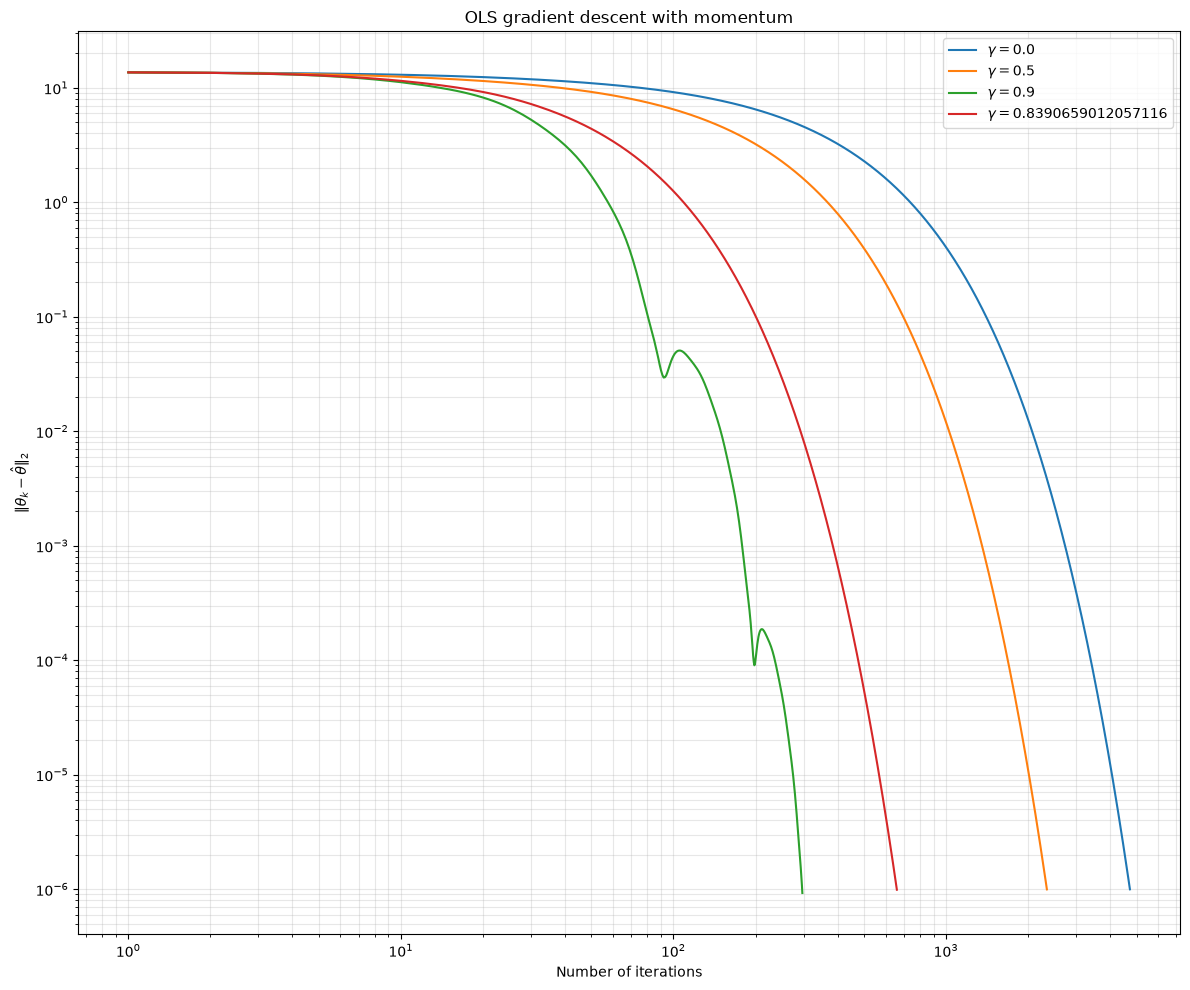

The condition number for this OLS was given by:  520.3442674565971
The square root of the condition number is therefore:  22.811055816349164
Dividing the square root of Kappa by Kappa itself should therefore yield a similar value as dividing the number of iterations for the correct gamma by the number of iterations with normal gradienet descent
This yields:  0.04383839170141694 which should roughly be equal to:  0.06283054791622594


In [45]:
gamma_values = [0.0, 0.5, 0.9]
tol_momentum = 1e-6
num_iterations = []

#Compute condition number to find optimal gamma
n_5 = X_5_norm.shape[0]
Hessian_OLS = 2/ n_5 * X_5_norm.T @ X_5_norm
eigen_OLS = np.linalg.eigvalsh(Hessian_OLS)
max_lam_OLS = np.max(eigen_OLS)
min_lam_OLS = np.min(eigen_OLS)
kappaOLS =  max_lam_OLS/min_lam_OLS
optimal_gamma = ((np.sqrt(kappaOLS) - 1)/(np.sqrt(kappaOLS) + 1))**2
gamma_values.append(optimal_gamma)

#Function to compute OLS using gradient descent with momentum
#Returns Distance to optimum for every iteration, Number of iterations needed and theta
def gd_OLS_w_momentum(X, y, gamma, num_iters, tol):
    n_samples, n_features = X.shape

    theta_opt = np.linalg.solve(X.T @ X, X.T @ y)
    theta = np.zeros(n_features)
    v = np.zeros(n_features)
    distances = []

    hessian = 2 / n_samples * (X.T @ X)
    lamda_max = np.linalg.eigvalsh(hessian).max()
    eta = 0.9 * 2 / lamda_max #Given in task

    for iteration in range(num_iters):
        gradient = grad_OLS(X, y, n_samples, theta)

        v = gamma * v + eta * gradient
        theta = theta - v

        distance = np.linalg.norm(theta - theta_opt)
        distances.append(distance)

        if distance < tol:
            return np.asarray(distances), iteration + 1, theta

    return np.asarray(distances), num_iters, theta

fig, ax = plt.subplots(figsize=(12, 10))
for gamma_value in gamma_values:
    distances, iterations, theta = gd_OLS_w_momentum(
        X_5_norm,
        y_centered,
        gamma_value,
        num_iters,
        tol_momentum
    )
    num_iterations.append(iterations)
    ax.loglog(
        np.arange(1, len(distances) + 1),
        distances,
        label=fr"$\gamma={gamma_value}$"
    )

    print(
        f"gamma={gamma_value}: "
        f"{iterations} iterations, "
        f"final distance={distances[-1]:.3e}"
    )

ax.set_xlabel("Number of iterations")
ax.set_ylabel(r"$\|\theta_k-\hat{\theta}\|_2$")
ax.set_title("OLS gradient descent with momentum")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print("The condition number for this OLS was given by: ", kappaOLS)
print("The square root of the condition number is therefore: ", np.sqrt(kappaOLS))
print("Dividing the square root of Kappa by Kappa itself should therefore yield a similar value as dividing the number of iterations for the correct gamma by the number of iterations with normal gradienet descent")
print("This yields: ", (np.sqrt(kappaOLS) / kappaOLS)**(1) , "which should roughly be equal to: ", (num_iterations[-2]/num_iterations[0])**(1))

The above plot shows the number of iterations plotted against the distance to the optimal solution on a double logarithmic  scale.

It is of note that for a $\gamma$, which is larger than the optimal momentum, the gradient descent solver no longer converges steadily, however it still needs less iterations than the optimal momentum parameter. One cause for this could be, because we are not using the correct $\eta$.

It can be seen that the division of the square root of Kappa by Kappa is roughly equal to the division of the number of iterations at gamma = 0.9 to the number of iterations needed for plain gradient descent.

6.3. The oscillations are being damped since a part of the last gradients is also added to the update formula. Therefore if a solution is oscillating the previous gradient will point in the opposite direction of the current gradient, thereby canceling the oscillations. 
For directions, which do not oscillate, the last gradient is pointing in the same direction as the current gradient, therefore the gradients get added together.

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| My loop stopped after its allowed iterations with a small but nonzero gradient. Has it converged? | No. Along the slowest direction the error contracts by $\lvert 1-\gamma\lambda_{\min}\rvert$ per step, Eq. (4.19), and can still be $\|\nabla C\|/\lambda_{\min}$ large. Stop on the gradient (or on $\Delta\boldsymbol{\theta}$), never on a count alone. |
| Why does gradient descent care about the scaling of the columns when the closed form does not? | The closed form solves the normal equations in one go; gradient descent takes the same step in every direction, and the column scales set the eigenvalue spread $\kappa(\boldsymbol{H}) = \kappa_2(\boldsymbol{X})^2$, Eq. (4.22), hence the iteration count. Same minimum, different road. |
| Ridge converged in far fewer iterations than OLS. Did it find a better OLS solution? | No — it found the exact solution of a *different* problem, Eq. (4.16). The penalty lifts $\lambda_{\min}$, Eq. (4.17), which shortens the road, but the destination moved: bias traded for variance. |
| The same code diverged at $\gamma = 0.5$ on one data set and converged at $\gamma = 0.8$ on another. Why? | Stability requires $\gamma < 2/\lambda_{\max}$, Eq. (4.20), and $\lambda_{\max}$ is a property of $\boldsymbol{X}$, not of the algorithm. Compute it — `np.linalg.eigvalsh(2/n * X.T @ X).max()` — before you choose $\gamma$. |
| The closed form and my converged gradient descent disagree in the second decimal for Ridge. Which is wrong? | Possibly neither: with the cost $\frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y}\|^2 + \lambda\|\boldsymbol{\theta}\|^2$ the closed form has $n\lambda\boldsymbol{I}$, Eq. (3.95), and `scikit-learn`'s `alpha` is $n\lambda$. Compare cost functions before comparing methods. |
| My JAX gradient agrees with my analytical gradient to $10^{-15}$. What have I proved? | That your derivation matches the cost you *wrote down* — an algebra error would show as $10^{-2}$. Not that the cost is the one you meant (a missing $1/n$, a penalised intercept): both gradients would then agree and both would be wrong. |
| Momentum converged where plain gradient descent diverged. Is the learning rate now unimportant? | No. The stability edge moves to $2(1+\beta)/\lambda_{\max}$, and the best $\beta$ is tied to $\kappa$ through Eq. (4.26); too much momentum rings for ever. Two data-dependent knobs instead of one. |
| Why does momentum help, in one sentence? | It adds up gradients that keep pointing the same way (the flat directions, effective step $\gamma/(1-\beta)$, Eq. (4.25)) and cancels gradients that alternate in sign (the steep direction), so the iteration count scales with $\sqrt\kappa$ instead of $\kappa$. |
| I swap the OLS cost for a neural-network cost and keep `jax.grad`. What changes? | In the code: only the definition of the cost. In the theory: convexity is gone, so a stationary point need not be the global minimum (Section 4.1) and the bound of Eq. (4.20) is only local — good behaviour becomes empirical, not a theorem. |
| Why reverse mode for training, and what is its price? | One scalar output and $p$ inputs: reverse mode returns the full gradient for two or three cost evaluations, whatever $p$ (the cheap gradient principle, Section 4.14.4); forward mode or finite differences would need $p$ sweeps. The price is the tape — every intermediate value is stored until the backward sweep has used it: memory, not time. |
| Why not just use finite differences to check the gradient, and be done with it? | For a *quadratic* cost the central difference is exact up to rounding, so it would pass; for anything else its best accuracy is about $10^{-11}$ at $h\approx10^{-6}$, Eq. (4.46), and it costs $2p$ evaluations. Use it as a check at $h \approx 10^{-5}$, not as the gradient. |

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 11 at midnight**. Collaboration is encouraged — list
your collaborators.